In [ ]:
!pip uninstall torch torchvision torchaudio
!pip install torch==2.3.1+cu121 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install mlatom==3.9.1

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Would remove:
    /usr/local/bin/torchfrtrace
    /usr/local/bin/torchrun
    /usr/local/lib/python3.11/dist-packages/functorch/*
    /usr/local/lib/python3.11/dist-packages/torch-2.6.0+cu124.dist-info/*
    /usr/local/lib/python3.11/dist-packages/torch/*
    /usr/local/lib/python3.11/dist-packages/torchgen/*
Proceed (Y/n)? Y
Y
Y
Y
Y
Y
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/torchvision-0.21.0+cu124.dist-info/*
    /usr/local/lib/python3.11/dist-packages/torchvision.libs/libcudart.41118559.so.12
    /usr/local/lib/python3.11/dist-packages/torchvision.libs/libjpeg.1c1c4b09.so.8
    /usr/local/lib/python3.11/dist-packages/torchvision.libs/libnvjpeg.02b6d700.so.12
    /usr/local/lib/python3.11/dist-packages/torchvision.libs/libpng16.0364a1db.so.16
    /u

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
!unzip ANI_ensemble_Force.zip

Archive:  ANI_ensemble_Force.zip
   creating: ANI_ensemble_Force/
   creating: ANI_ensemble_Force/DE1/
  inflating: ANI_ensemble_Force/DE1/ani_acrolein.pt  
  inflating: ANI_ensemble_Force/DE1/cis.npz  
  inflating: ANI_ensemble_Force/DE1/cis_trans.npz  
  inflating: ANI_ensemble_Force/DE1/test.npz  
  inflating: ANI_ensemble_Force/DE1/train.npz  
   creating: ANI_ensemble_Force/DE2/
  inflating: ANI_ensemble_Force/DE2/ani_acrolein.pt  
  inflating: ANI_ensemble_Force/DE2/cis.npz  
  inflating: ANI_ensemble_Force/DE2/cis_trans.npz  
  inflating: ANI_ensemble_Force/DE2/For_Acrolein_ANI_DE2.ipynb  
  inflating: ANI_ensemble_Force/DE2/test.npz  
  inflating: ANI_ensemble_Force/DE2/train.npz  
   creating: ANI_ensemble_Force/DE3/
  inflating: ANI_ensemble_Force/DE3/ani_acrolein.pt  
  inflating: ANI_ensemble_Force/DE3/cis.npz  
  inflating: ANI_ensemble_Force/DE3/cis_trans.npz  
  inflating: ANI_ensemble_Force/DE3/For_Acrolein_ANI_DE3.ipynb  
  inflating: ANI_ensemble_Force/DE3/test.npz  


In [ ]:
energy_data = []
grad_data = []
for i in range(1, 9):
    folder_name = f'ANI_ensemble_Force/DE{i}'
    file_path = os.path.join(folder_name, 'cis_trans.npz')
    ct_data = np.load(file_path)
    energy_data.append(ct_data['energy'])
    grad_data.append(ct_data['grad'])

ct_energy_data = np.array(energy_data)
ct_grad_data = np.array(grad_data)

In [ ]:
print('Energy data shape', ct_energy_data.shape)
print('Grad data shape', ct_grad_data.shape)
print('------------------------------------------------')
ct_energy_mean = np.mean(ct_energy_data, axis=0)
ct_energy_std = np.std(ct_energy_data, axis=0)

print('Energy Mean shape', ct_energy_mean.shape)
print('Energy Std shape', ct_energy_std.shape)
print('------------------------------------------------')
ct_grad_mean = np.mean(ct_grad_data, axis=0)
ct_grad_std = np.std(ct_grad_data, axis=0)

print('Grad Mean shape', ct_grad_mean.shape)
print('Grad Std shape', ct_grad_std.shape)

Energy data shape (8, 20000)
Grad data shape (8, 20000, 8, 3)
------------------------------------------------
Energy Mean shape (20000,)
Energy Std shape (20000,)
------------------------------------------------
Grad Mean shape (20000, 8, 3)
Grad Std shape (20000, 8, 3)


In [ ]:
model_5_en_pred = ct_energy_data[4, :].reshape(-1, 1)
model_5_for_pred = ct_grad_data[4, :, :]
# print(model_5_en_pred.shape)
# print(model_5_for_pred.shape)

In [ ]:
data = np.load('ws22_acrolein.npz')

for key, val in data.items():
    print(key, '->', val.shape)

coordinates_cis_trans = np.array(data['R'][:20000])
energy_cis_trans = np.array(data['E'][:20000])
grads_cis_trans = -np.array(data['F'][:20000])


atoms = []

for i in range(data['Z'].shape[0]):
    if data['Z'][i] == 6:
        atoms.append('C')
    elif data['Z'][i] == 8:
        atoms.append('O')
    elif data['Z'][i] == 1:
        atoms.append('H')

print(atoms)

R -> (120000, 8, 3)
F -> (120000, 8, 3)
Q -> (120000, 8, 1)
DP -> (120000, 3)
QP -> (120000, 3, 3)
P -> (120000, 6)
RC -> (120000, 3)
HL -> (120000, 2)
E -> (120000, 1)
Z -> (8,)
R2 -> (120000, 1)
CONF -> (120000, 1)
['C', 'O', 'C', 'C', 'H', 'H', 'H', 'H']


In [ ]:
print(energy_cis_trans.shape)
print(grads_cis_trans.shape)

(20000, 1)
(20000, 8, 3)


In [ ]:
print('r2 score (train) ->', r2_score(energy_cis_trans, model_5_en_pred))
print('MAE (train) ->', mean_absolute_error(energy_cis_trans, model_5_en_pred))

r2 score (train) -> 0.8400180823065131
MAE (train) -> 2.6279941986183797


In [ ]:
low_uncertain_indices = pd.read_csv('low_uncertainty_force_indices.csv')
low_uncertain_indices = np.array(low_uncertain_indices.values.flatten())
print(low_uncertain_indices)

[   17    18    19 ... 19997 19998 19999]


In [ ]:
from sklearn.metrics import mean_absolute_error

# Subset the true and predicted values using low_uncertain_indices
true_subset = energy_cis_trans[low_uncertain_indices]
pred_subset = model_5_en_pred[low_uncertain_indices]

# Calculate MAE for the subset
mae_low_uncertainty = mean_absolute_error(true_subset, pred_subset)
print('MAE (low uncertainty subset) ->', mae_low_uncertainty)

MAE (low uncertainty subset) -> 0.08418817650732653


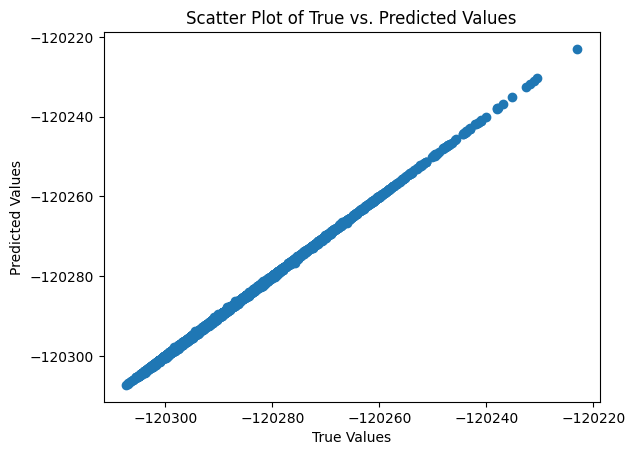

In [ ]:
plt.scatter(true_subset, pred_subset)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot of True vs. Predicted Values')
plt.show()

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split

data = np.load('ws22_acrolein.npz')
coordinates_trans = np.array(data['R'][70000:])
energy_trans = np.array(data['E'][70000:])
coordinates_trans_train, coordinates_trans_test, en_trans_train, en_trans_test = train_test_split(coordinates_trans, energy_trans, train_size = 0.90, random_state=0)

def r2_descriptor(xyz_matrix: np.ndarray) -> np.ndarray:
    """Build the pairwise atom-atom distance descriptor.

    Args:
    -----
        xyz_matrix: a numpy 3D tensor of shape (n_geometries, n_atoms, 3) containing the stacked
                    Cartesian coordinates of the molecular structures.

    Return:
    -------
        r2_matrix: a numpy 2D array of shape (n_geometries, n_atoms * (n_atoms - 1)/2) with the
                   unique pairwise distances vector calculated for each molecular geometry.
    """
    n_samples, n_atoms, _ = xyz_matrix.shape
    dist_vec_size = int(n_atoms * (n_atoms - 1)/2)
    r2_matrix = np.empty((n_samples, dist_vec_size))
    for idx in range(n_samples):
        distance_matrix = np.zeros((n_atoms, n_atoms))
        geom = xyz_matrix[idx]
        for i, j in combinations(range(len(geom)), 2):
            R = np.linalg.norm(geom[i] - geom[j])
            distance_matrix[j, i] = R
        r2_vector = distance_matrix[np.tril_indices(len(distance_matrix), -1)]
        r2_matrix[idx, :] = r2_vector.reshape(1,-1)
    return r2_matrix


r2_train = r2_descriptor(coordinates_trans_train)
print(r2_train.shape)
r2_test = r2_descriptor(coordinates_trans_test)
r2_cis_trans = r2_descriptor(np.array(data['R'][:20000]))
r2_cis = r2_descriptor(np.array(data['R'][20000:70000]))
print(r2_cis.shape)
full_data = np.append(np.append(np.append(r2_train, r2_test, axis=0), r2_cis_trans, axis=0), r2_cis, axis=0)
#full_data = np.append(r2_train, r2_test, axis=0)
print(full_data.shape)
X = MinMaxScaler().fit_transform(full_data)
print("Performing dimensionality reduction with PCA...\n")
pca_n2 = PCA(n_components=2)
pca_n2.fit(X)
X_transformed = pca_n2.transform(X)
print('Perfomed')

(45000, 28)
(50000, 28)
(120000, 28)
Performing dimensionality reduction with PCA...

Perfomed


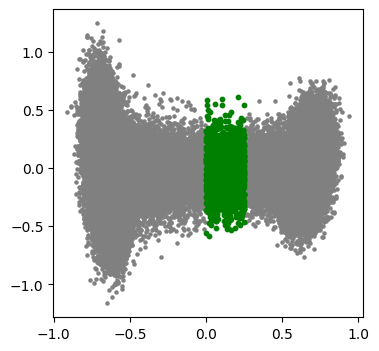

In [ ]:
# Original scatter plot (all points in gray)
plt.scatter(-X_transformed[:, 0], X_transformed[:, 1], c='gray', s=5)

# Get x and y values
x_vals = -X_transformed[:, 0]
y_vals = X_transformed[:, 1]

# Find indices where 0 < x < 0.5
selected_indices = np.where((x_vals > 0) & (x_vals < 0.25))[0]

# Plot selected points in green
plt.scatter(x_vals[selected_indices], y_vals[selected_indices], c='green', s=10)

# Set figure size
plt.gcf().set_size_inches(4, 4)
plt.show()

In [ ]:
test_indices = selected_indices - 50000
print(test_indices)

[   10    11    12 ... 19969 19992 19993]


In [ ]:
##Performance of the model on the test dataset with pretrained model

# Subset the true and predicted values using low_uncertain_indices
test_subset_true = energy_cis_trans[selected_indices - 50000]
test_subset_pred = model_5_en_pred[selected_indices - 50000]

# Calculate MAE for the subset
mae_test_uncertainty = mean_absolute_error(test_subset_true, test_subset_pred)
print('MAE (test subset with pretrained model) ->', mae_test_uncertainty)

MAE (test subset with pretrained model) -> 3.033991075505086


##Selection of points for training

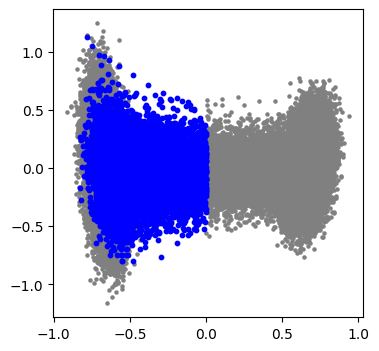

In [ ]:
# Original scatter plot (all points in gray)
plt.scatter(-X_transformed[:, 0], X_transformed[:, 1], c='gray', s=5)

# Get x and y values
x_vals = -X_transformed[50000:, 0]
y_vals = X_transformed[50000:, 1]

# Find indices where 0 < x < 0.5
selected_indices_train = np.where((x_vals < 0))[0]
selected_indices_train = selected_indices_train

# Plot selected points in green
plt.scatter(x_vals[selected_indices_train], y_vals[selected_indices_train], c='blue', s=10)

# Set figure size
plt.gcf().set_size_inches(4, 4)
plt.show()

In [ ]:
print(selected_indices_train.shape)
print(low_uncertain_indices.shape)

(10045,)
(4546,)


In [ ]:
# Check if all low_uncertain_indices are in selected_indices_train
is_subset = np.isin(low_uncertain_indices, selected_indices_train)
if np.all(is_subset):
    print("All low_uncertain_indices are present in selected_indices_train.")
else:
    print("Some low_uncertain_indices are NOT in selected_indices_train.")

# Remove low_uncertain_indices from selected_indices_train
filtered_train_indices = np.setdiff1d(selected_indices_train, low_uncertain_indices)

print("Filtered selected_indices_train shape:", filtered_train_indices.shape)


All low_uncertain_indices are present in selected_indices_train.
Filtered selected_indices_train shape: (5499,)


In [ ]:
import os

from mlatom.data import molecular_database, molecule
from mlatom.interfaces.torchani_interface import ani
# from mlatom.interfaces.gap_interface import gap
from mlatom import models
from mlatom.constants import Hartree2eV, Angstrom2Bohr, kcalpermol2eV
import torch

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

import ipywidgets as widgets
from ipywidgets import interact

In [ ]:
epots_train = energy_cis_trans[filtered_train_indices].flatten() * kcalpermol2eV
epots_test = energy_cis_trans[test_indices].flatten() * kcalpermol2eV
grads_train = grads_cis_trans[filtered_train_indices] * kcalpermol2eV
grads_test = grads_cis_trans[test_indices] * kcalpermol2eV

coordinates_train = coordinates_cis_trans[filtered_train_indices]
coordinates_test = coordinates_cis_trans[test_indices]

In [ ]:
print(epots_train.shape)
print(grads_train.shape)
print(epots_test.shape)
print(grads_test.shape)
print(coordinates_train.shape)
print(coordinates_test.shape)

(5499,)
(5499, 8, 3)
(2541,)
(2541, 8, 3)
(5499, 8, 3)
(2541, 8, 3)


In [ ]:
atoms = np.tile(np.array(1 * [6] + 1 * [8] + 2 * [6] + 4 * [1]), (5499, 1))
acrolein_train = molecular_database.from_numpy(coordinates_train, atoms)

In [ ]:
acrolein_train.element_symbols.shape

(5499, 8)

In [ ]:
acrolein_train.xyz_coordinates.shape

(5499, 8, 3)

In [ ]:
acrolein_train.add_scalar_properties(epots_train, "energy")

In [ ]:
acrolein_train.add_xyz_derivative_properties(grads_train, "energy", "energy_grad")

In [ ]:
acrolein_train.get_properties('energy').shape

(5499,)

In [ ]:
acrolein_train.get_xyz_derivative_properties('energy_grad').shape

(5499, 8, 3)

In [ ]:
import random
import torch
import os
import sys
import numpy as np
import pandas as pd
# import ulamdyn as ulmd
import torch
import torchani
from mlatom.data import molecular_database, molecule
from mlatom.interfaces.torchani_interface import ani
from mlatom.constants import Hartree2eV, Angstrom2Bohr

In [ ]:
def set_seed(seed):
    # Set the seed for the Python random module
    random.seed(seed)

    # Set the seed for NumPy
    np.random.seed(seed)

    # Set the seed for PyTorch (CPU)
    torch.manual_seed(seed)

    # If using a GPU, set the seed for PyTorch (GPU)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.

    # Ensure deterministic behavior for some operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set a seed value
seed = 0
set_seed(seed)

In [ ]:
hyperparams = models.hyperparameters({
        #### Training ####
        'batch_size':           models.hyperparameter(value=128, minval=1, maxval=1024, optimization_space='linear', dtype=int),
        'max_epochs':           models.hyperparameter(value=1000, minval=100, maxval=1000000, optimization_space='log', dtype=int),
        'learning_rate':                    models.hyperparameter(value=0.002, minval=0.0001, maxval=0.01, optimization_space='log'),
        'early_stopping_learning_rate':     models.hyperparameter(value=1.0E-7, minval=1.0E-6, maxval=1.0E-4, optimization_space='log'),
        'lr_reduce_patience':   models.hyperparameter(value=50, minval=16, maxval=256, optimization_space='linear'),
        'lr_reduce_factor':     models.hyperparameter(value=0.8, minval=0.1, maxval=0.9, optimization_space='linear'),
        'lr_reduce_threshold':  models.hyperparameter(value=0.0, minval=-0.01, maxval=0.01, optimization_space='linear'),
        #### Loss ####
        'force_coefficient':    models.hyperparameter(value=0.1, minval=0.05, maxval=5, optimization_space='linear'),
        'median_loss':          models.hyperparameter(value=False),
        'validation_loss_type': models.hyperparameter(value='mean_RMSE', choices=['MSE', 'mean_RMSE']),
        #### Network ####
        "neurons":              models.hyperparameter(value=[[72, 64, 64, 16]]),
        "activation_function":  models.hyperparameter(value=lambda: torch.nn.CELU(), optimization_space='choice', choices=["CELU", "ReLU", "GELU"]),
        "fixed_layers":         models.hyperparameter(value=False),
        #### AEV ####
        'Rcr':                  models.hyperparameter(value=5.2000e+00, minval=1.0, maxval=10.0, optimization_space='linear'),
        'Rca':                  models.hyperparameter(value=3.5000e+00, minval=1.0, maxval=10.0, optimization_space='linear'),
        'EtaR':                 models.hyperparameter(value=[1.6000000e+01]),
        'ShfR':                 models.hyperparameter(value=[9.0000000e-01, 1.1687500e+00, 1.4375000e+00, 1.7062500e+00, 1.9750000e+00, 2.2437500e+00, 2.5125000e+00, 2.7812500e+00, 3.0500000e+00, 3.3187500e+00, 3.5875000e+00, 3.8562500e+00, 4.1250000e+00, 4.3937500e+00, 4.6625000e+00, 4.9312500e+00]),
        'Zeta':                 models.hyperparameter(value=[3.2000000e+01]),
        'ShfZ':                 models.hyperparameter(value=[1.9634954e-01, 5.8904862e-01, 9.8174770e-01, 1.3744468e+00, 1.7671459e+00, 2.1598449e+00, 2.5525440e+00, 2.9452431e+00]),
        'EtaA':                 models.hyperparameter(value=[8.0000000e+00]),
        'ShfA':                 models.hyperparameter(value=[9.0000000e-01, 1.5500000e+00, 2.2000000e+00, 2.8500000e+00]),
    })

In [ ]:
# import torch
# import numpy

# # Allow numpy scalar unpickling (safe if file is trusted)
# torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])

model_ani = ani("/content/ani_acrolein.pt")
model_ani.hyperparameters = hyperparams


model loaded from /content/ani_acrolein.pt


In [ ]:
model_ani.train(
    molecular_database=acrolein_train,
    property_to_learn="energy",
    xyz_derivative_property_to_learn="energy_grad",
    save_model=True,
)

Sequential(
  (0): AEVComputer()
  (1): ANIModel(
    (C): Sequential(
      (0): Linear(in_features=240, out_features=72, bias=True)
      (1): CELU(alpha=1.0)
      (2): Linear(in_features=72, out_features=64, bias=True)
      (3): CELU(alpha=1.0)
      (4): Linear(in_features=64, out_features=64, bias=True)
      (5): CELU(alpha=1.0)
      (6): Linear(in_features=64, out_features=16, bias=True)
      (7): CELU(alpha=1.0)
      (8): Linear(in_features=16, out_features=1, bias=True)
    )
    (H): Sequential(
      (0): Linear(in_features=240, out_features=72, bias=True)
      (1): CELU(alpha=1.0)
      (2): Linear(in_features=72, out_features=64, bias=True)
      (3): CELU(alpha=1.0)
      (4): Linear(in_features=64, out_features=64, bias=True)
      (5): CELU(alpha=1.0)
      (6): Linear(in_features=64, out_features=16, bias=True)
      (7): CELU(alpha=1.0)
      (8): Linear(in_features=16, out_features=1, bias=True)
    )
    (O): Sequential(
      (0): Linear(in_features=240, out_

epoch 1: 100%|██████████| 35/35 [00:04<00:00,  8.44it/s]


validation loss: 0.002818309339610013 at epoch 2
learning_rate: 0.001
model saved in /content/ani_acrolein.pt


epoch 2: 100%|██████████| 35/35 [00:04<00:00,  8.52it/s]


validation loss: 0.0016301796382123773 at epoch 3
learning_rate: 0.001
model saved in /content/ani_acrolein.pt


...

validation loss: 0.0002650318040766499 at epoch 999
learning_rate: 1.5625e-05
model saved in /content/ani_acrolein.pt


epoch 999: 100%|██████████| 35/35 [00:05<00:00,  6.89it/s]


validation loss: 0.0002650171721523458 at epoch 1000
learning_rate: 1.5625e-05
model saved in /content/ani_acrolein.pt


epoch 1000: 100%|██████████| 35/35 [00:04<00:00,  7.75it/s]


model loaded from /content/ani_acrolein.pt


In [ ]:
atoms = np.tile(np.array(1 * [6] + 1 * [8] + 2 * [6] + 4 * [1]), (2541, 1))
acrolein_test = molecular_database.from_numpy(coordinates_test, atoms)

In [ ]:
acrolein_test.add_scalar_properties(epots_test, "energy")

In [ ]:
acrolein_test.add_xyz_derivative_properties(grads_test, "energy", "energy_grad")

In [ ]:
acrolein_test.size

2541

In [ ]:
mcd_test_mol = acrolein_test.copy()
model_ani.predict(
    molecular_database=mcd_test_mol,
    property_to_predict="energy",
    xyz_derivative_property_to_predict="energy_grad",
    batch_size=100,
)
# mcd_test_mol.get_properties("energy")
# mcd_test_mol.get_xyz_derivative_properties("energy_grad")
np.savez('test_calibrated.npz', energy=np.array(mcd_test_mol.get_properties("energy")) /kcalpermol2eV, grad=np.array(mcd_test_mol.get_xyz_derivative_properties("energy_grad")) / kcalpermol2eV)

In [ ]:
mse_epot = np.mean(
    ((mcd_test_mol.get_properties("energy") - acrolein_test.get_properties("energy")))** 2)
print(np.sqrt(mse_epot) / kcalpermol2eV)
mse_grad = np.mean(
    (
        (
            mcd_test_mol.get_xyz_derivative_properties("energy_grad")
            - acrolein_test.get_xyz_derivative_properties("energy_grad")
        )
    )
    ** 2
)
print(np.sqrt(mse_grad) / kcalpermol2eV)

0.23817574677796524
1.2064017377533007
